## 用卷积神经网络训练Cifar10
For this tutorial, we will use the CIFAR10 dataset. It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’, ‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

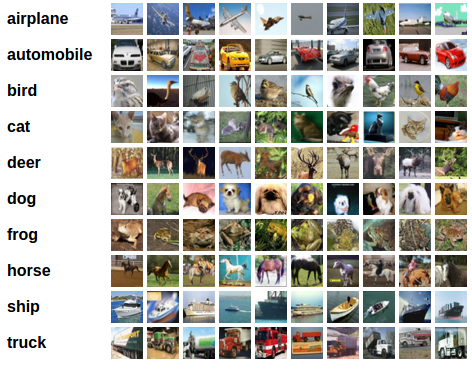

## Training an image classifier
We will do the following steps in order:
- Load and normalize the CIFAR10 training and test datasets using torchvision
- Define a Convolutional Neural Network
- Define a loss function
- Train the network on the training data
- Test the network on the test data

## 1. Load and normalize CIFAR10
Using torchvision, it's extremely easy to load CIFAR10.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

The output of torchvision datasets are PILImage images of range [0, 1]. We transform them to Tensors of normalized range [-1, 1].

In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


Let us show some of the training images, for fun.

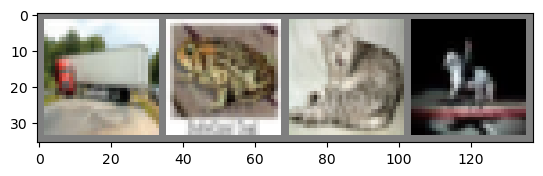

truck frog  cat   horse


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## 2. Define a Convolutional Neural Network


In [4]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # 4, 6, 28, 28
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
#         x = self.conv1(x)
#         print("output shape of conv1:", x.size())
#         x = F.relu(x)
        
#         x = self.pool(x)
        
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

## 3. Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## 4. Train the network
This is when things start to get interesting. We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [6]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.272
[1,  4000] loss: 1.943
[1,  6000] loss: 1.696
[1,  8000] loss: 1.586
[1, 10000] loss: 1.506
[1, 12000] loss: 1.453
[2,  2000] loss: 1.379
[2,  4000] loss: 1.373
[2,  6000] loss: 1.341
[2,  8000] loss: 1.317
[2, 10000] loss: 1.313
[2, 12000] loss: 1.282
Finished Training


In [7]:
PATH = './original_net.pth'
torch.save(net.state_dict(), PATH)

## 5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

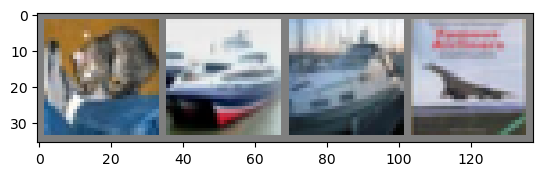

GroundTruth:  cat   ship  ship  plane


In [8]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let’s load back in our saved model (note: saving and re-loading the model wasn’t necessary here, we only did it to illustrate how to do so):

In [9]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are:

In [12]:
outputs = net(images)

The outputs are energies for the 10 classes. The higher the energy for a class, the more the network thinks that the image is of the particular class. So, let’s get the index of the highest energy:

In [13]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   ship  ship  ship 


The results seem pretty good.

Let us look at how the network performs on the whole dataset.

In [14]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 53 %


Let’s quickly save our trained model:

That looks way better than chance, which is 10% accuracy (randomly picking a class out of 10 classes). Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did not perform well:

In [15]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 38.7 %
Accuracy for class: car   is 60.0 %
Accuracy for class: bird  is 40.4 %
Accuracy for class: cat   is 19.7 %
Accuracy for class: deer  is 41.2 %
Accuracy for class: dog   is 56.4 %
Accuracy for class: frog  is 68.7 %
Accuracy for class: horse is 79.9 %
Accuracy for class: ship  is 61.1 %
Accuracy for class: truck is 65.9 %


Using device: cpu
Epoch [1/20] - lr: 0.01000, train_loss: 2.0728, val_loss: 1.6903, train_acc: 38.57%, val_acc: 38.47%
Epoch [2/20] - lr: 0.00994, train_loss: 1.5480, val_loss: 1.4531, train_acc: 47.55%, val_acc: 47.32%
Epoch [3/20] - lr: 0.00976, train_loss: 1.3813, val_loss: 1.3566, train_acc: 51.34%, val_acc: 50.09%
Epoch [4/20] - lr: 0.00946, train_loss: 1.2792, val_loss: 1.2551, train_acc: 56.73%, val_acc: 55.57%
Epoch [5/20] - lr: 0.00905, train_loss: 1.1883, val_loss: 1.2256, train_acc: 59.51%, val_acc: 57.32%
Epoch [6/20] - lr: 0.00854, train_loss: 1.1143, val_loss: 1.1565, train_acc: 62.61%, val_acc: 58.77%
Epoch [7/20] - lr: 0.00794, train_loss: 1.0630, val_loss: 1.1317, train_acc: 63.82%, val_acc: 60.18%
Epoch [8/20] - lr: 0.00727, train_loss: 1.0062, val_loss: 1.1067, train_acc: 66.47%, val_acc: 60.94%
Epoch [9/20] - lr: 0.00655, train_loss: 0.9619, val_loss: 1.0871, train_acc: 67.82%, val_acc: 61.98%
Epoch [10/20] - lr: 0.00578, train_loss: 0.9190, val_loss: 1.0639, train_

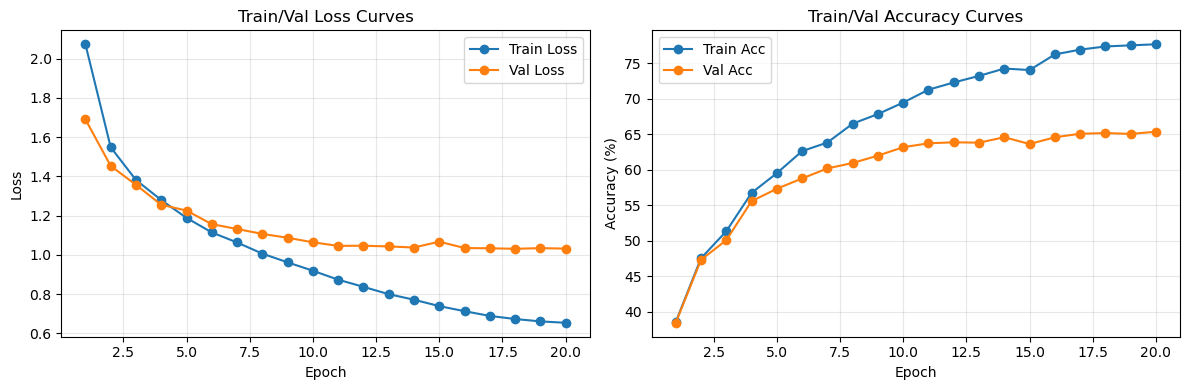

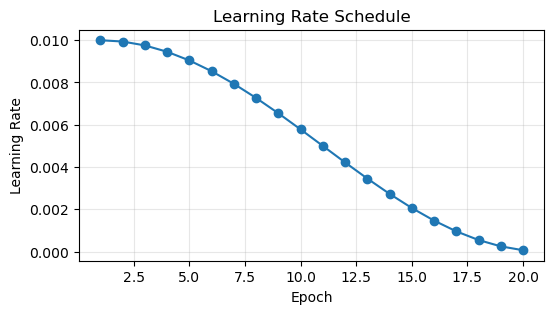

Final train_loss: 0.6539
Best train_loss : 0.6539
Final val_loss  : 1.0317
Best val_loss   : 1.0309
Final train_acc : 77.64%
Best train_acc  : 77.64%
Final val_acc   : 65.34%
Best val_acc    : 65.34%


In [21]:
# 训练并记录曲线（与上面演示分离，避免污染已有 net）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# 为了更快画曲线，这里使用更大的 batch size；不影响结论趋势
curve_batch_size = 128
curve_trainloader = torch.utils.data.DataLoader(trainset, batch_size=curve_batch_size, shuffle=True, num_workers=2)
curve_testloader = torch.utils.data.DataLoader(testset, batch_size=curve_batch_size, shuffle=False, num_workers=2)

net_curve = Net().to(device)
criterion_curve = nn.CrossEntropyLoss()

# 调参：提高初始学习率并增加权重衰减，配合调度器让后期更稳定
initial_lr = 0.01
momentum = 0.9
weight_decay = 5e-4
optimizer_curve = optim.SGD(
    net_curve.parameters(),
    lr=initial_lr,
    momentum=momentum,
    weight_decay=weight_decay,
)

# 训练轮数改为 20，并使用余弦退火让学习率逐步下降到更平稳区间
epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_curve, T_max=epochs)

train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []
lr_list = []

for epoch in range(epochs):
    net_curve.train()
    train_loss_sum = 0.0
    train_sample_count = 0

    for inputs, labels in curve_trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_curve.zero_grad()
        outputs = net_curve(inputs)
        loss = criterion_curve(outputs, labels)
        loss.backward()
        optimizer_curve.step()

        batch_size_now = labels.size(0)
        train_loss_sum += loss.item() * batch_size_now
        train_sample_count += batch_size_now

    avg_train_loss = train_loss_sum / train_sample_count
    train_loss_list.append(avg_train_loss)

    net_curve.eval()

    # 每个 epoch 后统计训练集准确率
    train_correct = 0
    train_total = 0
    with torch.no_grad():
        for inputs, labels in curve_trainloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = net_curve(inputs)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

    train_acc = 100.0 * train_correct / train_total
    train_acc_list.append(train_acc)

    # 每个 epoch 后统计验证集 loss 和准确率
    val_loss_sum = 0.0
    val_sample_count = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in curve_testloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = net_curve(inputs)

            vloss = criterion_curve(outputs, labels)
            batch_size_now = labels.size(0)
            val_loss_sum += vloss.item() * batch_size_now
            val_sample_count += batch_size_now

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss_sum / val_sample_count
    val_loss_list.append(avg_val_loss)

    val_acc = 100.0 * val_correct / val_total
    val_acc_list.append(val_acc)

    current_lr = optimizer_curve.param_groups[0]['lr']
    lr_list.append(current_lr)

    print(
        f"Epoch [{epoch + 1}/{epochs}] - "
        f"lr: {current_lr:.5f}, "
        f"train_loss: {avg_train_loss:.4f}, "
        f"val_loss: {avg_val_loss:.4f}, "
        f"train_acc: {train_acc:.2f}%, "
        f"val_acc: {val_acc:.2f}%"
    )

    scheduler.step()

# 画图
epoch_idx = list(range(1, epochs + 1))
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_idx, train_loss_list, marker='o', label='Train Loss')
plt.plot(epoch_idx, val_loss_list, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Val Loss Curves')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_idx, train_acc_list, marker='o', label='Train Acc')
plt.plot(epoch_idx, val_acc_list, marker='o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train/Val Accuracy Curves')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 额外画学习率变化，便于解释“为何后期更稳定”
plt.figure(figsize=(6, 3))
plt.plot(epoch_idx, lr_list, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(alpha=0.3)
plt.show()

print(f"Final train_loss: {train_loss_list[-1]:.4f}")
print(f"Best train_loss : {min(train_loss_list):.4f}")
print(f"Final val_loss  : {val_loss_list[-1]:.4f}")
print(f"Best val_loss   : {min(val_loss_list):.4f}")
print(f"Final train_acc : {train_acc_list[-1]:.2f}%")
print(f"Best train_acc  : {max(train_acc_list):.2f}%")
print(f"Final val_acc   : {val_acc_list[-1]:.2f}%")
print(f"Best val_acc    : {max(val_acc_list):.2f}%")

In [23]:
# 保存20轮训练得到的模型参数（来自 net_curve）
save_path = 'original_best_model.pth'
torch.save(net_curve.state_dict(), save_path)
print(f'Model saved to: {save_path}')

Model saved to: original_best_model.pth


In [19]:
# 仅用缓存画图，不训练
# 兼容旧变量名（你上一次运行用的是 train_loss_history）
if 'train_loss_list' not in globals() and 'train_loss_history' in globals():
    train_loss_list = train_loss_history

required_vars = ['train_acc_list', 'val_acc_list', 'train_loss_list', 'val_loss_list']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print('缺少以下缓存变量，当前无法直接画四条曲线:')
    print('  ' + ', '.join(missing_vars))
    print('说明：你上一次运行没有记录 val_loss_list，所以双损失曲线无法从旧数据恢复。')
    print('解决：只需重跑一次上面的训练单元，之后本单元即可反复秒级重画。')
else:
    n = min(len(train_loss_list), len(val_loss_list), len(train_acc_list), len(val_acc_list))
    epoch_idx = list(range(1, n + 1))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epoch_idx, train_loss_list[:n], marker='o', label='Train Loss')
    plt.plot(epoch_idx, val_loss_list[:n], marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train/Val Loss Curves (Cached)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epoch_idx, train_acc_list[:n], marker='o', label='Train Acc')
    plt.plot(epoch_idx, val_acc_list[:n], marker='o', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Train/Val Accuracy Curves (Cached)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Cached final train_loss: {train_loss_list[n - 1]:.4f}")
    print(f"Cached final val_loss  : {val_loss_list[n - 1]:.4f}")
    print(f"Cached final train_acc : {train_acc_list[n - 1]:.2f}%")
    print(f"Cached final val_acc   : {val_acc_list[n - 1]:.2f}%")

缺少以下缓存变量，当前无法直接画四条曲线:
  val_loss_list
说明：你上一次运行没有记录 val_loss_list，所以双损失曲线无法从旧数据恢复。
解决：只需重跑一次上面的训练单元，之后本单元即可反复秒级重画。


## 7. 仅使用已有缓存数据画图（不重新训练）
这个单元不会训练模型，只会尝试使用当前内存里的列表画图。若缺少 `val_loss_list`，会提示你必须至少重跑一次训练单元来补齐该数据。

## 6. 训练 Loss 曲线与验证准确率曲线
下面这个单元会重新初始化一个模型，按 epoch 训练，并在每个 epoch 结束后在 CIFAR10 测试集上评估准确率，最后画出两条曲线。

In [1]:
# MiniResNet 网络定义（适配 CIFAR-10）
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    # 基础残差块：两层 3x3 卷积 + BN + ReLU
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 当输入输出维度不一致时，使用 1x1 卷积对齐（下采样）
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)

        # 跳跃连接：输入直接加到输出上
        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = F.relu(out, inplace=True)
        return out


class MiniResNet(nn.Module):
    # 参考 ResNet-18 的精简版：3个 stage，每个 stage 含2个残差块
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 16

        # 初始层：3x3 卷积 + BN + ReLU（不做大步长下采样，适合 CIFAR-10）
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        # 残差阶段：16 -> 32 -> 64
        self.layer1 = self._make_layer(16, blocks=2, stride=1)
        self.layer2 = self._make_layer(32, blocks=2, stride=2)
        self.layer3 = self._make_layer(64, blocks=2, stride=2)

        # 输出层：全局平均池化 + 全连接
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = [ResidualBlock(self.in_channels, out_channels, stride=stride)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# 实例化并打印结构，便于检查
mini_resnet = MiniResNet(num_classes=10)
print(mini_resnet)

MiniResNet(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, e

Using device: cpu
Files already downloaded and verified
Files already downloaded and verified
Epoch [1/20] - lr: 0.01000, train_loss: 1.5639, train_acc: 41.73%, val_loss: 1.3558, val_acc: 52.87%
Epoch [2/20] - lr: 0.00994, train_loss: 1.1175, train_acc: 59.95%, val_loss: 1.2619, val_acc: 57.04%
Epoch [3/20] - lr: 0.00976, train_loss: 0.9516, train_acc: 66.23%, val_loss: 1.0939, val_acc: 63.34%
Epoch [4/20] - lr: 0.00946, train_loss: 0.8412, train_acc: 70.28%, val_loss: 0.9587, val_acc: 67.45%
Epoch [5/20] - lr: 0.00905, train_loss: 0.7538, train_acc: 73.65%, val_loss: 0.7938, val_acc: 72.54%
Epoch [6/20] - lr: 0.00854, train_loss: 0.6906, train_acc: 75.75%, val_loss: 0.7389, val_acc: 75.05%
Epoch [7/20] - lr: 0.00794, train_loss: 0.6396, train_acc: 77.67%, val_loss: 0.6922, val_acc: 77.53%
Epoch [8/20] - lr: 0.00727, train_loss: 0.6009, train_acc: 79.27%, val_loss: 0.7047, val_acc: 76.12%
Epoch [9/20] - lr: 0.00655, train_loss: 0.5641, train_acc: 80.54%, val_loss: 0.6266, val_acc: 78.7

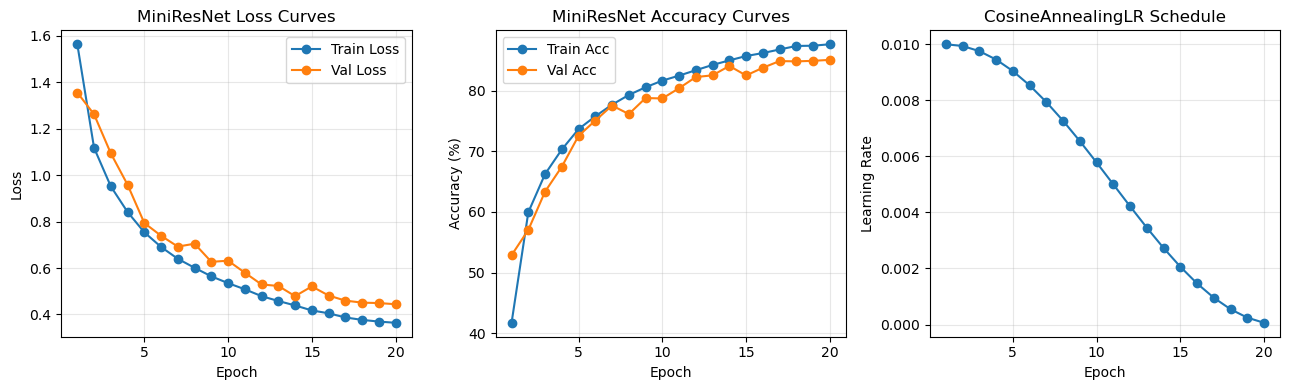

In [2]:
# MiniResNet 训练单元（含数据增强 + SGD + CosineAnnealingLR + 曲线绘制）
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# 数据增强：训练集使用随机裁剪+随机翻转，测试集只做标准归一化
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 重新构建 CIFAR-10 数据集和加载器
batch_size_resnet = 128

trainset_resnet = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader_resnet = torch.utils.data.DataLoader(trainset_resnet, batch_size=batch_size_resnet, shuffle=True, num_workers=2)

testset_resnet = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader_resnet = torch.utils.data.DataLoader(testset_resnet, batch_size=batch_size_resnet, shuffle=False, num_workers=2)

# 模型、损失函数、优化器、学习率调度器
mini_resnet = MiniResNet(num_classes=10).to(device)
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.SGD(mini_resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_resnet = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=20)

# 训练配置
epochs_resnet = 20
train_loss_list_resnet = []
val_loss_list_resnet = []
train_acc_list_resnet = []
val_acc_list_resnet = []
lr_list_resnet = []

best_val_acc_resnet = 0.0
best_model_path_resnet = 'mini_resnet_best.pth'

for epoch in range(epochs_resnet):
    # ===== 训练阶段 =====
    mini_resnet.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader_resnet:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = mini_resnet(inputs)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        train_loss_sum += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss_sum / train_total
    train_acc = 100.0 * train_correct / train_total
    train_loss_list_resnet.append(avg_train_loss)
    train_acc_list_resnet.append(train_acc)

    # ===== 验证阶段 =====
    mini_resnet.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in testloader_resnet:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = mini_resnet(inputs)
            loss = criterion_resnet(outputs, labels)

            val_loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss_sum / val_total
    val_acc = 100.0 * val_correct / val_total
    val_loss_list_resnet.append(avg_val_loss)
    val_acc_list_resnet.append(val_acc)

    # 记录当前学习率
    current_lr = optimizer_resnet.param_groups[0]['lr']
    lr_list_resnet.append(current_lr)

    # 保存最佳模型
    if val_acc > best_val_acc_resnet:
        best_val_acc_resnet = val_acc
        torch.save(mini_resnet.state_dict(), best_model_path_resnet)

    print(
        f"Epoch [{epoch + 1}/{epochs_resnet}] - "
        f"lr: {current_lr:.5f}, "
        f"train_loss: {avg_train_loss:.4f}, train_acc: {train_acc:.2f}%, "
        f"val_loss: {avg_val_loss:.4f}, val_acc: {val_acc:.2f}%"
    )

    scheduler_resnet.step()

print(f'Best val_acc: {best_val_acc_resnet:.2f}%')
print(f'Best model saved to: {best_model_path_resnet}')

# ===== 曲线绘制 =====
epoch_idx = list(range(1, epochs_resnet + 1))

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(epoch_idx, train_loss_list_resnet, marker='o', label='Train Loss')
plt.plot(epoch_idx, val_loss_list_resnet, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MiniResNet Loss Curves')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epoch_idx, train_acc_list_resnet, marker='o', label='Train Acc')
plt.plot(epoch_idx, val_acc_list_resnet, marker='o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('MiniResNet Accuracy Curves')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(epoch_idx, lr_list_resnet, marker='o', label='LR')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('CosineAnnealingLR Schedule')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
# Cell 1: 定义 DenseBlock 和 Transition
# OpenMP 冲突修复：必须放在导入 torch 之前
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')

import torch
import torch.nn as nn
import torch.nn.functional as F


class DenseLayer(nn.Module):
    # 单层稠密层：BN -> ReLU -> Conv(3x3)
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, stride=1, padding=1, bias=False)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        # 稠密连接：沿通道维拼接输入与新特征
        out = torch.cat([x, out], dim=1)
        return out


class DenseBlock(nn.Module):
    # 稠密块：由 n_layers 个 DenseLayer 堆叠组成
    def __init__(self, in_channels, growth_rate, n_layers):
        super().__init__()
        layers = []
        channels = in_channels
        for _ in range(n_layers):
            layers.append(DenseLayer(channels, growth_rate))
            channels += growth_rate
        self.block = nn.Sequential(*layers)
        self.out_channels = channels

    def forward(self, x):
        return self.block(x)


class Transition(nn.Module):
    # 过渡层：BN -> ReLU -> Conv(1x1) -> AvgPool(2x2)
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(self.relu(self.bn(x)))
        x = self.pool(x)
        return x

In [2]:
# Cell 2: 定义 MiniDenseNet 主网络

class MiniDenseNet(nn.Module):
    # 微型 DenseNet：初始卷积 + 3个 DenseBlock + 2个 Transition + GAP + FC
    def __init__(self, growth_rate=12, n_layers_per_block=4, init_channels=24, num_classes=10, compression=0.5):
        super().__init__()

        # 初始层
        self.stem = nn.Conv2d(3, init_channels, kernel_size=3, stride=1, padding=1, bias=False)
        channels = init_channels

        # Dense Block 1
        self.block1 = DenseBlock(channels, growth_rate, n_layers_per_block)
        channels = self.block1.out_channels
        t1_out = int(channels * compression)
        self.trans1 = Transition(channels, t1_out)
        channels = t1_out

        # Dense Block 2
        self.block2 = DenseBlock(channels, growth_rate, n_layers_per_block)
        channels = self.block2.out_channels
        t2_out = int(channels * compression)
        self.trans2 = Transition(channels, t2_out)
        channels = t2_out

        # Dense Block 3
        self.block3 = DenseBlock(channels, growth_rate, n_layers_per_block)
        channels = self.block3.out_channels

        # 输出层
        self.bn_last = nn.BatchNorm2d(channels)
        self.relu_last = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.trans1(x)
        x = self.block2(x)
        x = self.trans2(x)
        x = self.block3(x)
        x = self.relu_last(self.bn_last(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# 结构检查
mini_densenet = MiniDenseNet(growth_rate=12, n_layers_per_block=4, init_channels=24, num_classes=10)
print(mini_densenet)

MiniDenseNet(
  (stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (block1): DenseBlock(
    (block): Sequential(
      (0): DenseLayer(
        (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv): Conv2d(24, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (1): DenseLayer(
        (bn): BatchNorm2d(36, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv): Conv2d(36, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (2): DenseLayer(
        (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv): Conv2d(48, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (3): DenseLayer(
        (bn): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=Tru

Using device: cuda
Files already downloaded and verified
Files already downloaded and verified


C:\Users\19753\AppData\Local\Temp\ipykernel_16544\3302246905.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)
C:\Users\19753\AppData\Local\Temp\ipykernel_16544\3302246905.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you 

Resume from epoch 21/20
Best val_acc_dense: 84.74%
Best model saved to: mini_densenet_best.pth
Last checkpoint saved to: mini_densenet_last.pth


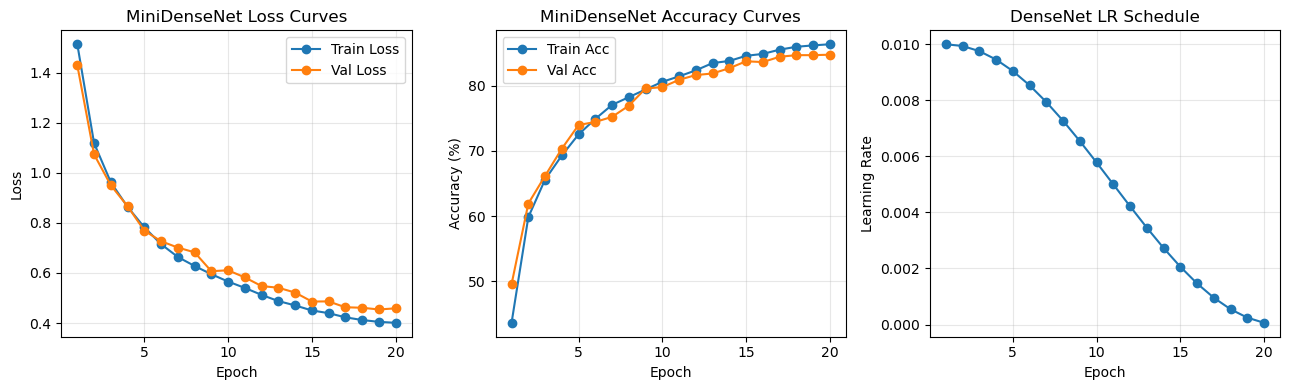

In [3]:
# Cell 3: 训练循环（if __name__ == '__main__' 便于后续导出为 .py）
import os
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

if __name__ == '__main__':
    # 设备配置（GPU 可用时启用 cudnn benchmark 提升卷积性能）
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        torch.backends.cudnn.benchmark = True
    print('Using device:', device)

    # 数据增强（DenseNet 训练同样使用增强来抑制过拟合）
    transform_train_dense = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    transform_test_dense = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # 为了稳定性降低显存压力：batch_size 改为 32
    batch_size_dense = 32

    trainset_dense = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_dense)
    testset_dense = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test_dense)

    # 为减少 Windows 下 DataLoader 相关崩溃风险，num_workers=0
    use_pin_memory = use_cuda
    trainloader_dense = torch.utils.data.DataLoader(
        trainset_dense,
        batch_size=batch_size_dense,
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    testloader_dense = torch.utils.data.DataLoader(
        testset_dense,
        batch_size=batch_size_dense,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    # 模型与优化器
    model_dense = MiniDenseNet(growth_rate=12, n_layers_per_block=4, init_channels=24, num_classes=10).to(device)
    criterion_dense = nn.CrossEntropyLoss()
    optimizer_dense = optim.SGD(model_dense.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

    # 学习率调度
    epochs_dense = 20
    scheduler_dense = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_dense, T_max=epochs_dense)

    # AMP 混合精度（仅 CUDA 时启用）
    scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)

    # 训练记录
    train_loss_list_dense = []
    val_loss_list_dense = []
    train_acc_list_dense = []
    val_acc_list_dense = []
    lr_list_dense = []

    best_val_acc_dense = 0.0
    best_model_path_dense = 'mini_densenet_best.pth'
    checkpoint_path_dense = 'mini_densenet_last.pth'

    # 支持断点续训：如存在上次未跑完的 last checkpoint，自动接着跑
    start_epoch = 0
    if os.path.exists(checkpoint_path_dense):
        ckpt = torch.load(checkpoint_path_dense, map_location=device)
        model_dense.load_state_dict(ckpt['model'])
        optimizer_dense.load_state_dict(ckpt['optimizer'])
        scheduler_dense.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
        start_epoch = ckpt['epoch'] + 1
        train_loss_list_dense = ckpt['train_loss_list']
        val_loss_list_dense = ckpt['val_loss_list']
        train_acc_list_dense = ckpt['train_acc_list']
        val_acc_list_dense = ckpt['val_acc_list']
        lr_list_dense = ckpt['lr_list']
        best_val_acc_dense = ckpt['best_val_acc']
        print(f'Resume from epoch {start_epoch + 1}/{epochs_dense}')

    for epoch in range(start_epoch, epochs_dense):
        # ===== 训练阶段 =====
        model_dense.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader_dense:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer_dense.zero_grad(set_to_none=True)

            try:
                with torch.cuda.amp.autocast(enabled=use_cuda):
                    outputs = model_dense(inputs)
                    loss = criterion_dense(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer_dense)
                scaler.update()

            except RuntimeError as e:
                # 遇到 OOM 时跳过该 batch，避免整个 kernel 崩溃
                if 'out of memory' in str(e).lower():
                    print('Warning: CUDA OOM, skip one batch...')
                    optimizer_dense.zero_grad(set_to_none=True)
                    if use_cuda:
                        torch.cuda.empty_cache()
                    continue
                else:
                    raise

            train_loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss_sum / max(train_total, 1)
        train_acc = 100.0 * train_correct / max(train_total, 1)
        train_loss_list_dense.append(avg_train_loss)
        train_acc_list_dense.append(train_acc)

        # ===== 验证阶段 =====
        model_dense.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in testloader_dense:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_cuda):
                    outputs = model_dense(inputs)
                    loss = criterion_dense(outputs, labels)

                val_loss_sum += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss_sum / max(val_total, 1)
        val_acc = 100.0 * val_correct / max(val_total, 1)
        val_loss_list_dense.append(avg_val_loss)
        val_acc_list_dense.append(val_acc)

        current_lr = optimizer_dense.param_groups[0]['lr']
        lr_list_dense.append(current_lr)

        if val_acc > best_val_acc_dense:
            best_val_acc_dense = val_acc
            torch.save(model_dense.state_dict(), best_model_path_dense)

        print(
            f"Epoch [{epoch + 1}/{epochs_dense}] - "
            f"lr: {current_lr:.5f}, "
            f"train_loss: {avg_train_loss:.4f}, train_acc: {train_acc:.2f}%, "
            f"val_loss: {avg_val_loss:.4f}, val_acc: {val_acc:.2f}%"
        )

        scheduler_dense.step()

        # 每轮保存 last checkpoint，便于崩溃后续跑
        torch.save({
            'epoch': epoch,
            'model': model_dense.state_dict(),
            'optimizer': optimizer_dense.state_dict(),
            'scheduler': scheduler_dense.state_dict(),
            'scaler': scaler.state_dict(),
            'train_loss_list': train_loss_list_dense,
            'val_loss_list': val_loss_list_dense,
            'train_acc_list': train_acc_list_dense,
            'val_acc_list': val_acc_list_dense,
            'lr_list': lr_list_dense,
            'best_val_acc': best_val_acc_dense,
        }, checkpoint_path_dense)

        if use_cuda:
            torch.cuda.empty_cache()

    print(f'Best val_acc_dense: {best_val_acc_dense:.2f}%')
    print(f'Best model saved to: {best_model_path_dense}')
    print(f'Last checkpoint saved to: {checkpoint_path_dense}')

    # ===== 曲线绘制 =====
    epoch_idx = list(range(1, len(train_loss_list_dense) + 1))

    plt.figure(figsize=(13, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epoch_idx, train_loss_list_dense, marker='o', label='Train Loss')
    plt.plot(epoch_idx, val_loss_list_dense, marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('MiniDenseNet Loss Curves')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epoch_idx, train_acc_list_dense, marker='o', label='Train Acc')
    plt.plot(epoch_idx, val_acc_list_dense, marker='o', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('MiniDenseNet Accuracy Curves')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epoch_idx, lr_list_dense, marker='o', label='LR')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('DenseNet LR Schedule')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. Mini SE-ResNet（GPU训练）
下面新增 SE-ResNet 版本：先定义 `SELayer` 与 `SEResidualBlock`，再在 `if __name__ == '__main__':` 中完成训练与可视化。

In [4]:
# Cell 1: 定义 SELayer / SEResidualBlock / MiniSEResNet
import torch
import torch.nn as nn
import torch.nn.functional as F


class SELayer(nn.Module):
    # Squeeze-and-Excitation: GAP -> FC(reduction) -> ReLU -> FC -> Sigmoid
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class SEResidualBlock(nn.Module):
    # 两层 3x3 卷积 + BN + ReLU，并在第二层卷积后插入 SE
    def __init__(self, in_channels, out_channels, stride=1, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SELayer(out_channels, reduction=reduction)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = F.relu(out, inplace=True)
        return out


class MiniSEResNet(nn.Module):
    # CIFAR-10 版本：stem(3x3) + 3 stages x 2 blocks + GAP + FC
    def __init__(self, num_classes=10, reduction=16):
        super().__init__()
        self.in_channels = 16

        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(16, blocks=2, stride=1, reduction=reduction)
        self.layer2 = self._make_layer(32, blocks=2, stride=2, reduction=reduction)
        self.layer3 = self._make_layer(64, blocks=2, stride=2, reduction=reduction)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels, blocks, stride, reduction):
        layers = [SEResidualBlock(self.in_channels, out_channels, stride=stride, reduction=reduction)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(SEResidualBlock(self.in_channels, out_channels, stride=1, reduction=reduction))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# 结构检查
mini_se_resnet = MiniSEResNet(num_classes=10, reduction=16)
print(mini_se_resnet)

MiniSEResNet(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): SEResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): SELayer(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=16, out_features=4, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=16, bias=False)
          (3): Sigmoid()
        )
      )
    )
    (1): SEResidualB

Using device: cuda
Files already downloaded and verified
Files already downloaded and verified


Using device: cuda
Files already downloaded and verified
Files already downloaded and verified
Epoch [1/20] - lr: 0.10000, train_loss: 1.5696, train_acc: 41.07%, val_loss: 1.3812, val_acc: 51.03%
Epoch [2/20] - lr: 0.09938, train_loss: 1.0829, train_acc: 60.91%, val_loss: 1.1518, val_acc: 58.94%
Epoch [3/20] - lr: 0.09755, train_loss: 0.8777, train_acc: 68.64%, val_loss: 0.8820, val_acc: 68.48%
Epoch [4/20] - lr: 0.09455, train_loss: 0.7736, train_acc: 72.95%, val_loss: 0.7559, val_acc: 73.72%
Epoch [5/20] - lr: 0.09045, train_loss: 0.7044, train_acc: 75.63%, val_loss: 0.8327, val_acc: 71.63%
Epoch [6/20] - lr: 0.08536, train_loss: 0.6541, train_acc: 77.47%, val_loss: 0.8179, val_acc: 72.23%
Epoch [7/20] - lr: 0.07939, train_loss: 0.6139, train_acc: 78.85%, val_loss: 0.6964, val_acc: 76.29%
Epoch [8/20] - lr: 0.07270, train_loss: 0.5844, train_acc: 79.80%, val_loss: 0.7928, val_acc: 73.55%
Epoch [9/20] - lr: 0.06545, train_loss: 0.5533, train_acc: 80.67%, val_loss: 0.9980, val_acc: 69.

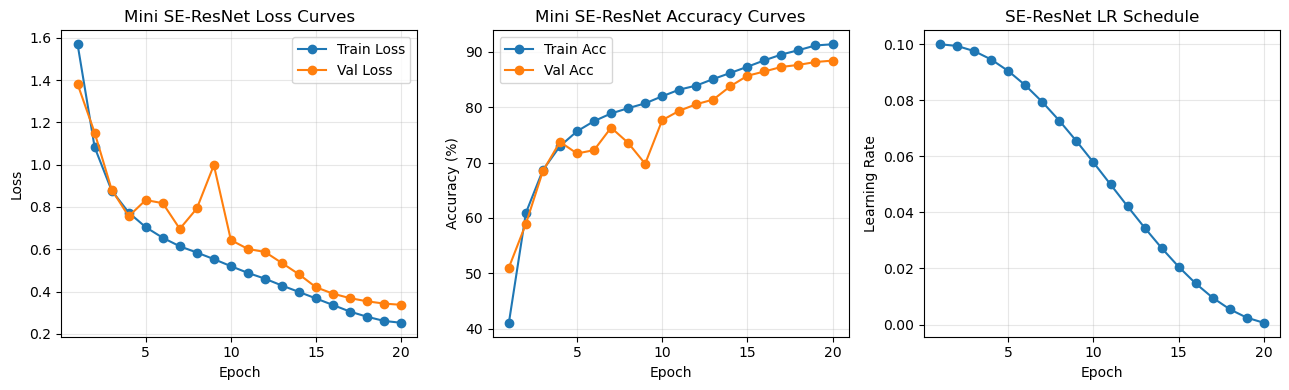

In [5]:
# Cell 2: GPU 训练流程（if __name__ == '__main__'）
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

if __name__ == '__main__':
    # 1) 设备检测与搬运
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)

    # 2) 数据增强与归一化
    transform_train_se = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    transform_test_se = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    # 3) 数据集与加载器
    batch_size_se = 128
    trainset_se = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_se)
    testset_se = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test_se)

    trainloader_se = torch.utils.data.DataLoader(
        trainset_se,
        batch_size=batch_size_se,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    testloader_se = torch.utils.data.DataLoader(
        testset_se,
        batch_size=batch_size_se,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # 4) 模型、损失、优化器、调度器
    model_se = MiniSEResNet(num_classes=10, reduction=16).to(device)
    criterion_se = nn.CrossEntropyLoss()
    optimizer_se = optim.SGD(
        model_se.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4,
    )
    epochs_se = 20
    scheduler_se = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_se, T_max=epochs_se)

    train_loss_list_se = []
    val_loss_list_se = []
    train_acc_list_se = []
    val_acc_list_se = []
    lr_list_se = []

    best_val_acc_se = 0.0
    best_model_path_se = 'mini_se_resnet_best.pth'

    for epoch in range(epochs_se):
        # ===== Train =====
        model_se.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader_se:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer_se.zero_grad()
            outputs = model_se(inputs)
            loss = criterion_se(outputs, labels)
            loss.backward()
            optimizer_se.step()

            train_loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss_sum / train_total
        train_acc = 100.0 * train_correct / train_total
        train_loss_list_se.append(avg_train_loss)
        train_acc_list_se.append(train_acc)

        # ===== Validation =====
        model_se.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in testloader_se:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model_se(inputs)
                loss = criterion_se(outputs, labels)

                val_loss_sum += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss_sum / val_total
        val_acc = 100.0 * val_correct / val_total
        val_loss_list_se.append(avg_val_loss)
        val_acc_list_se.append(val_acc)

        current_lr = optimizer_se.param_groups[0]['lr']
        lr_list_se.append(current_lr)

        if val_acc > best_val_acc_se:
            best_val_acc_se = val_acc
            torch.save(model_se.state_dict(), best_model_path_se)

        print(
            f"Epoch [{epoch + 1}/{epochs_se}] - "
            f"lr: {current_lr:.5f}, "
            f"train_loss: {avg_train_loss:.4f}, train_acc: {train_acc:.2f}%, "
            f"val_loss: {avg_val_loss:.4f}, val_acc: {val_acc:.2f}%"
        )

        scheduler_se.step()

    print(f'Best val_acc_se: {best_val_acc_se:.2f}%')
    print(f'Best model saved to: {best_model_path_se}')

    # 5) 曲线绘制
    epoch_idx = list(range(1, epochs_se + 1))

    plt.figure(figsize=(13, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epoch_idx, train_loss_list_se, marker='o', label='Train Loss')
    plt.plot(epoch_idx, val_loss_list_se, marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Mini SE-ResNet Loss Curves')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epoch_idx, train_acc_list_se, marker='o', label='Train Acc')
    plt.plot(epoch_idx, val_acc_list_se, marker='o', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Mini SE-ResNet Accuracy Curves')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epoch_idx, lr_list_se, marker='o', label='LR')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('SE-ResNet LR Schedule')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()